In [1]:
import numpy as np
import networkx as nx
from scipy.ndimage import binary_dilation
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
from skimage import measure
import skimage as ski
import dask.array as da
from scipy.spatial import ConvexHull, Delaunay, delaunay_plot_2d, convex_hull_plot_2d
import scipy.ndimage as ndi
import ast
from extract_features import subimage
from collections import defaultdict
from misc_utils import fixup_scipy_ndimage_result as fix
from misc_utils import strel_disk
import plotly.express as px
from dask.distributed import Client
import dask.delayed
import seaborn as sns
import scipy.signal
from brieflow_segment_utils import dask_image_log_scale, reconcile_nuclei_cells
from find_neighbors import objects_bounds, neighbors_for_object
from scipy.spatial import cKDTree

In [ ]:
import importlib
import find_neighbors
importlib.reload(find_neighbors)
from find_neighbors import objects_bounds, neighbors_for_object

In [2]:
nuclei_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day24_s12_nuclei_mask.tif"
foci_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day24_s12_foci.tif"
cyto_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day24_s12_cytoplasm_mask.tif"
cy5_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12_cy5.ome.tif"
gfp_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12_gfp.ome.tif"
df_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12.csv"

cy5 = tifffile.memmap(cy5_path, mode='r')
gfp = tifffile.memmap(gfp_path, mode='r')
nuclei = tifffile.memmap(nuclei_mask_path, mode='r')
cells = tifffile.memmap(cyto_mask_path, mode='r')
foci = tifffile.memmap(foci_mask_path, mode='r')

df = pd.read_csv(df_path, index_col="label",converters={"cells_bounds":ast.literal_eval})
# df["log_foci_count"] = np.log1p(df["foci_count"])

In [7]:
df["rebound"] = df[["colony_id"]]!=-1
df

,nucleus_i,nucleus_j,nucleus_area,nucleus_intensity_mean,nucleus_intensity_max,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,nucleus_bbox,cells_i,...,cells_intensity_max,cells_intensity_min,cells_intensity_std,cells_eccentricity,cells_bbox,foci_count,foci_area,log_foci_count,colony_id,rebound
label,,,,,,,,,,,,,,,,,,,,,
1,1626.883277,25270.540965,891.0,1978.325477,2737.0,1050.0,309.008268,0.738422,"(1608, 25256, 1648, 25286)",1647.967552,...,1905.0,47.0,288.821367,0.846173,"(1591, 25229, 1705, 25300)",4,68,1.609438,-1,False
2,1835.930929,22568.027629,1303.0,1049.079048,1759.0,127.0,256.589810,0.449434,"(1817, 22547, 1857, 22589)",1819.838183,...,816.0,75.0,124.181846,0.908882,"(1751, 22528, 1894, 22599)",0,0,0.000000,-1,False
3,2176.944855,17439.551452,2031.0,1243.318562,2284.0,392.0,320.720693,0.842334,"(2139, 17419, 2210, 17462)",2157.529913,...,3806.0,90.0,364.154363,0.874689,"(2072, 17396, 2228, 17509)",9,187,2.302585,-1,False
4,2329.479097,15284.986622,1196.0,2106.295987,3273.0,971.0,319.053239,0.682809,"(2312, 15263, 2348, 15307)",2319.671948,...,3114.0,71.0,643.213243,0.945546,"(2256, 15204, 2357, 15381)",1,15,0.693147,-1,False
5,2759.036096,23822.888592,2244.0,1020.229055,2011.0,129.0,346.619807,0.657179,"(2729, 23802, 2790, 23847)",2758.164241,...,1096.0,105.0,131.581688,0.407405,"(2710, 23766, 2813, 23857)",2,19,1.098612,-1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4503,38996.207165,18905.823209,2568.0,347.663551,1498.0,0.0,324.780798,0.595340,"(38969, 18875, 39025, 18934)",39002.306309,...,12959.0,805.0,2812.661711,0.436902,"(38970, 18871, 39038, 18934)",10,316,2.397895,-1,False
4504,39120.218018,18871.498643,5894.0,243.138785,766.0,0.0,166.041430,0.841621,"(39067, 18826, 39174, 18914)",39126.217714,...,8271.0,810.0,1317.646505,0.883823,"(39054, 18820, 39215, 18914)",17,434,2.890372,-1,False
4505,39259.623499,20067.005146,2332.0,153.511578,335.0,21.0,56.489220,0.721664,"(39228, 20042, 39291, 20092)",39239.245672,...,4412.0,500.0,666.589439,0.853813,"(39170, 20019, 39334, 20106)",4,69,1.609438,-1,False


In [102]:
group = df.groupby("colony_id")["foci_count"].mean()
more = group>group[-1]
moryes=list(more[more.values==True].index)

In [119]:
moryes

[2, 3, 6, 7, 19]

In [110]:
df["colony_id"].map(more).values

array([False, False, False, ..., False, False, False], shape=(4507,))

In [124]:
df["colony_id"][1]

np.int64(-1)

In [ ]:
is

In [127]:
df["foci_vs_rebound"] = ["more" if df["colony_id"][i] in moryes else ("less" if df["colony_id"][i] != -1 else "no_rebound") for i in df.index]


In [128]:
df

,nucleus_i,nucleus_j,nucleus_area,nucleus_intensity_mean,nucleus_intensity_max,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,nucleus_bbox,cells_i,...,cells_intensity_min,cells_intensity_std,cells_eccentricity,cells_bbox,foci_count,foci_area,log_foci_count,colony_id,rebound,foci_vs_rebound
label,,,,,,,,,,,,,,,,,,,,,
1,1626.883277,25270.540965,891.0,1978.325477,2737.0,1050.0,309.008268,0.738422,"(1608, 25256, 1648, 25286)",1647.967552,...,47.0,288.821367,0.846173,"(1591, 25229, 1705, 25300)",4,68,1.609438,-1,False,no_rebound
2,1835.930929,22568.027629,1303.0,1049.079048,1759.0,127.0,256.589810,0.449434,"(1817, 22547, 1857, 22589)",1819.838183,...,75.0,124.181846,0.908882,"(1751, 22528, 1894, 22599)",0,0,0.000000,-1,False,no_rebound
3,2176.944855,17439.551452,2031.0,1243.318562,2284.0,392.0,320.720693,0.842334,"(2139, 17419, 2210, 17462)",2157.529913,...,90.0,364.154363,0.874689,"(2072, 17396, 2228, 17509)",9,187,2.302585,-1,False,no_rebound
4,2329.479097,15284.986622,1196.0,2106.295987,3273.0,971.0,319.053239,0.682809,"(2312, 15263, 2348, 15307)",2319.671948,...,71.0,643.213243,0.945546,"(2256, 15204, 2357, 15381)",1,15,0.693147,-1,False,no_rebound
5,2759.036096,23822.888592,2244.0,1020.229055,2011.0,129.0,346.619807,0.657179,"(2729, 23802, 2790, 23847)",2758.164241,...,105.0,131.581688,0.407405,"(2710, 23766, 2813, 23857)",2,19,1.098612,-1,False,no_rebound
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4503,38996.207165,18905.823209,2568.0,347.663551,1498.0,0.0,324.780798,0.595340,"(38969, 18875, 39025, 18934)",39002.306309,...,805.0,2812.661711,0.436902,"(38970, 18871, 39038, 18934)",10,316,2.397895,-1,False,no_rebound
4504,39120.218018,18871.498643,5894.0,243.138785,766.0,0.0,166.041430,0.841621,"(39067, 18826, 39174, 18914)",39126.217714,...,810.0,1317.646505,0.883823,"(39054, 18820, 39215, 18914)",17,434,2.890372,-1,False,no_rebound
4505,39259.623499,20067.005146,2332.0,153.511578,335.0,21.0,56.489220,0.721664,"(39228, 20042, 39291, 20092)",39239.245672,...,500.0,666.589439,0.853813,"(39170, 20019, 39334, 20106)",4,69,1.609438,-1,False,no_rebound


<Axes: xlabel='foci_count', ylabel='Density'>

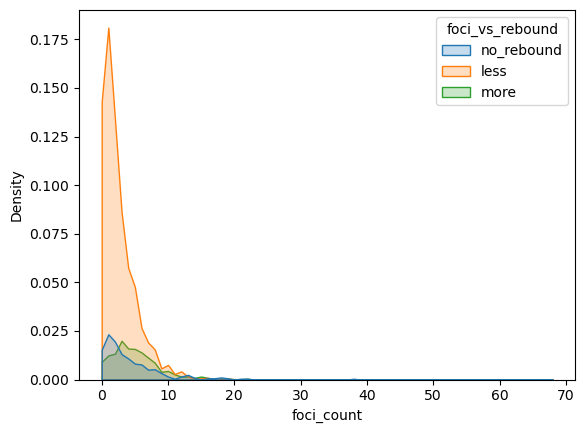

In [143]:
sns.histplot(data=df,x="foci_count",hue="foci_vs_rebound",multiple="layer",stat="density",discrete=True,element="poly")

In [ ]:
coords = df[["nucleus_i", "nucleus_j"]].values
tree = cKDTree(coords)
distances, indices = tree.query(coords, k=6)
nearest_dist = distances[:, 1]
alpha = 2.5   # scaling factor
local_radius = np.clip(alpha * nearest_dist, 20, 150).astype(int)
distances = local_radius
distances_list = distances.tolist()

In [ ]:
coords = df[["nucleus_i", "nucleus_j"]].values
tree = cKDTree(coords)
distances, indices = tree.query(coords, k=6)
rk = distances[:,5]
alpha =0.75
density_k5 = 5 / (np.pi * rk**2)
local_radius_i = np.clip(alpha / np.sqrt(density_k5), 20, 175).astype(int)
distances_list = local_radius_i.tolist()


In [ ]:
nobjects = np.max(cells)
object_indexes = np.arange(nobjects, dtype=np.int32) + 1
# distance = 75
# strel = strel_disk(distance)

minimums_i, maximums_i, minimums_j, maximums_j = objects_bounds(cells, distances_list)

client = Client()
futures = client.map(
    neighbors_for_object,
    object_indexes.tolist(),
    minimums_i.tolist(),
    maximums_i.tolist(),
    minimums_j.tolist(),
    maximums_j.tolist(),
    [cyto_mask_path] * len(object_indexes),
    distances_list,
)

result = client.gather(futures)

client.close()

edges = [edge for sublist in result for edge in sublist]

In [ ]:
G = nx.Graph()
G.add_nodes_from(object_indexes)
G.add_edges_from(edges)
components = list(nx.connected_components(G))
colony_map = {}
i = 1
for comp in components:
    if len(comp) < 15:
        for cell_id in comp:
            colony_map[cell_id] = -1
    else:
        for cell_id in comp:
            colony_map[cell_id] = i
        i += 1
df["colony_id"] = df.index.map(colony_map)
np.unique(df["colony_id"].values)

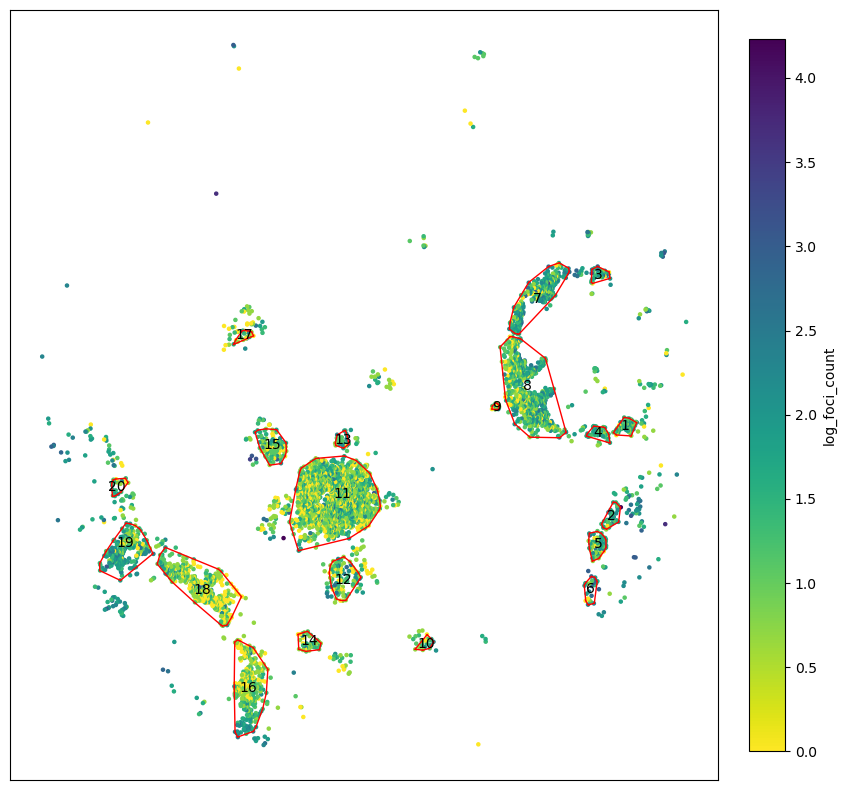

In [10]:
fig, ax = plt.subplots(figsize=(10,10))

for colony_id, subdf in df.groupby("colony_id"):
    if colony_id == -1:
        continue
    points = subdf[['cells_i', 'cells_j']].to_numpy()
    hull = ConvexHull(points)

    # draw edges
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1],
                color='red', linewidth=1)
    # compute centroid of hull
    centroid = points[hull.vertices].mean(axis=0)
    # label
    ax.text(
        centroid[0],
        centroid[1],
        str(colony_id),
        color='black',
        fontsize=10,
        ha='center',
        va='center'
    )

sc = ax.scatter(
    df["nucleus_i"],
    df["nucleus_j"],
    c=(df["log_foci_count"]),
    s=5,
    cmap="viridis_r"
) 
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label = "log_foci_count")
ax.set_xticks([])
ax.set_yticks([])
ax.invert_xaxis()
plt.show()

In [ ]:
df[df["colony_id"]==19].sort_values

,nucleus_i,nucleus_j,nucleus_area,nucleus_intensity_mean,nucleus_intensity_max,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,nucleus_bbox,cells_i,...,cells_intensity_mean,cells_intensity_max,cells_intensity_min,cells_intensity_std,cells_eccentricity,cells_bbox,foci_count,foci_area,log_foci_count,colony_id
label,,,,,,,,,,,,,,,,,,,,,
4156,33095.771429,13368.175714,2100.0,4765.231429,10614.0,470.0,2207.546065,0.842413,"(33070, 13338, 33125, 13398)",33123.981145,...,1031.256619,4987.0,148.0,643.490530,0.948223,"(33063, 13308, 33194, 13442)",9,249,2.302585,19
4159,33309.003508,13653.799018,2851.0,2119.203437,4507.0,167.0,897.764418,0.775557,"(33276, 13626, 33346, 13687)",33316.180325,...,595.723827,1173.0,158.0,230.323270,0.899817,"(33262, 13585, 33379, 13800)",1,9,0.693147,19
4160,33363.924651,13496.999070,2150.0,3164.301860,8840.0,65.0,2333.773155,0.929002,"(33327, 13471, 33400, 13527)",33322.112667,...,919.859112,2459.0,166.0,598.534691,0.973461,"(33253, 13413, 33379, 13522)",12,218,2.564949,19
4162,33453.313339,13774.660654,2384.0,2420.320889,5638.0,74.0,1308.296031,0.869335,"(33413, 13755, 33492, 13800)",33442.008781,...,649.269586,1655.0,146.0,295.127710,0.955722,"(33343, 13752, 33577, 13851)",1,21,0.693147,19
4163,33463.672921,13530.116948,1599.0,4237.572233,10745.0,70.0,2920.204670,0.933297,"(33431, 13510, 33498, 13551)",33467.199485,...,1466.083858,3637.0,194.0,720.390815,0.931950,"(33412, 13502, 33525, 13557)",10,196,2.397895,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4472,36032.654609,12545.397247,3124.0,661.442702,1577.0,41.0,342.067336,0.785494,"(36003, 12508, 36067, 12581)",36041.949774,...,1295.887913,4459.0,257.0,728.161228,0.917705,"(35968, 12493, 36115, 12633)",7,212,2.079442,19
4473,36112.791621,12649.766262,907.0,1392.482911,4072.0,71.0,1019.964996,0.502055,"(36095, 12635, 36131, 12666)",36121.100268,...,1276.102592,4854.0,267.0,991.354782,0.493024,"(36078, 12584, 36167, 12678)",6,132,1.945910,19
4475,36231.579710,12805.905797,1380.0,1177.878261,2946.0,103.0,666.654181,0.351746,"(36212, 12785, 36252, 12827)",36226.816137,...,1177.625917,2894.0,264.0,600.043048,0.666181,"(36190, 12775, 36259, 12863)",3,47,1.386294,19


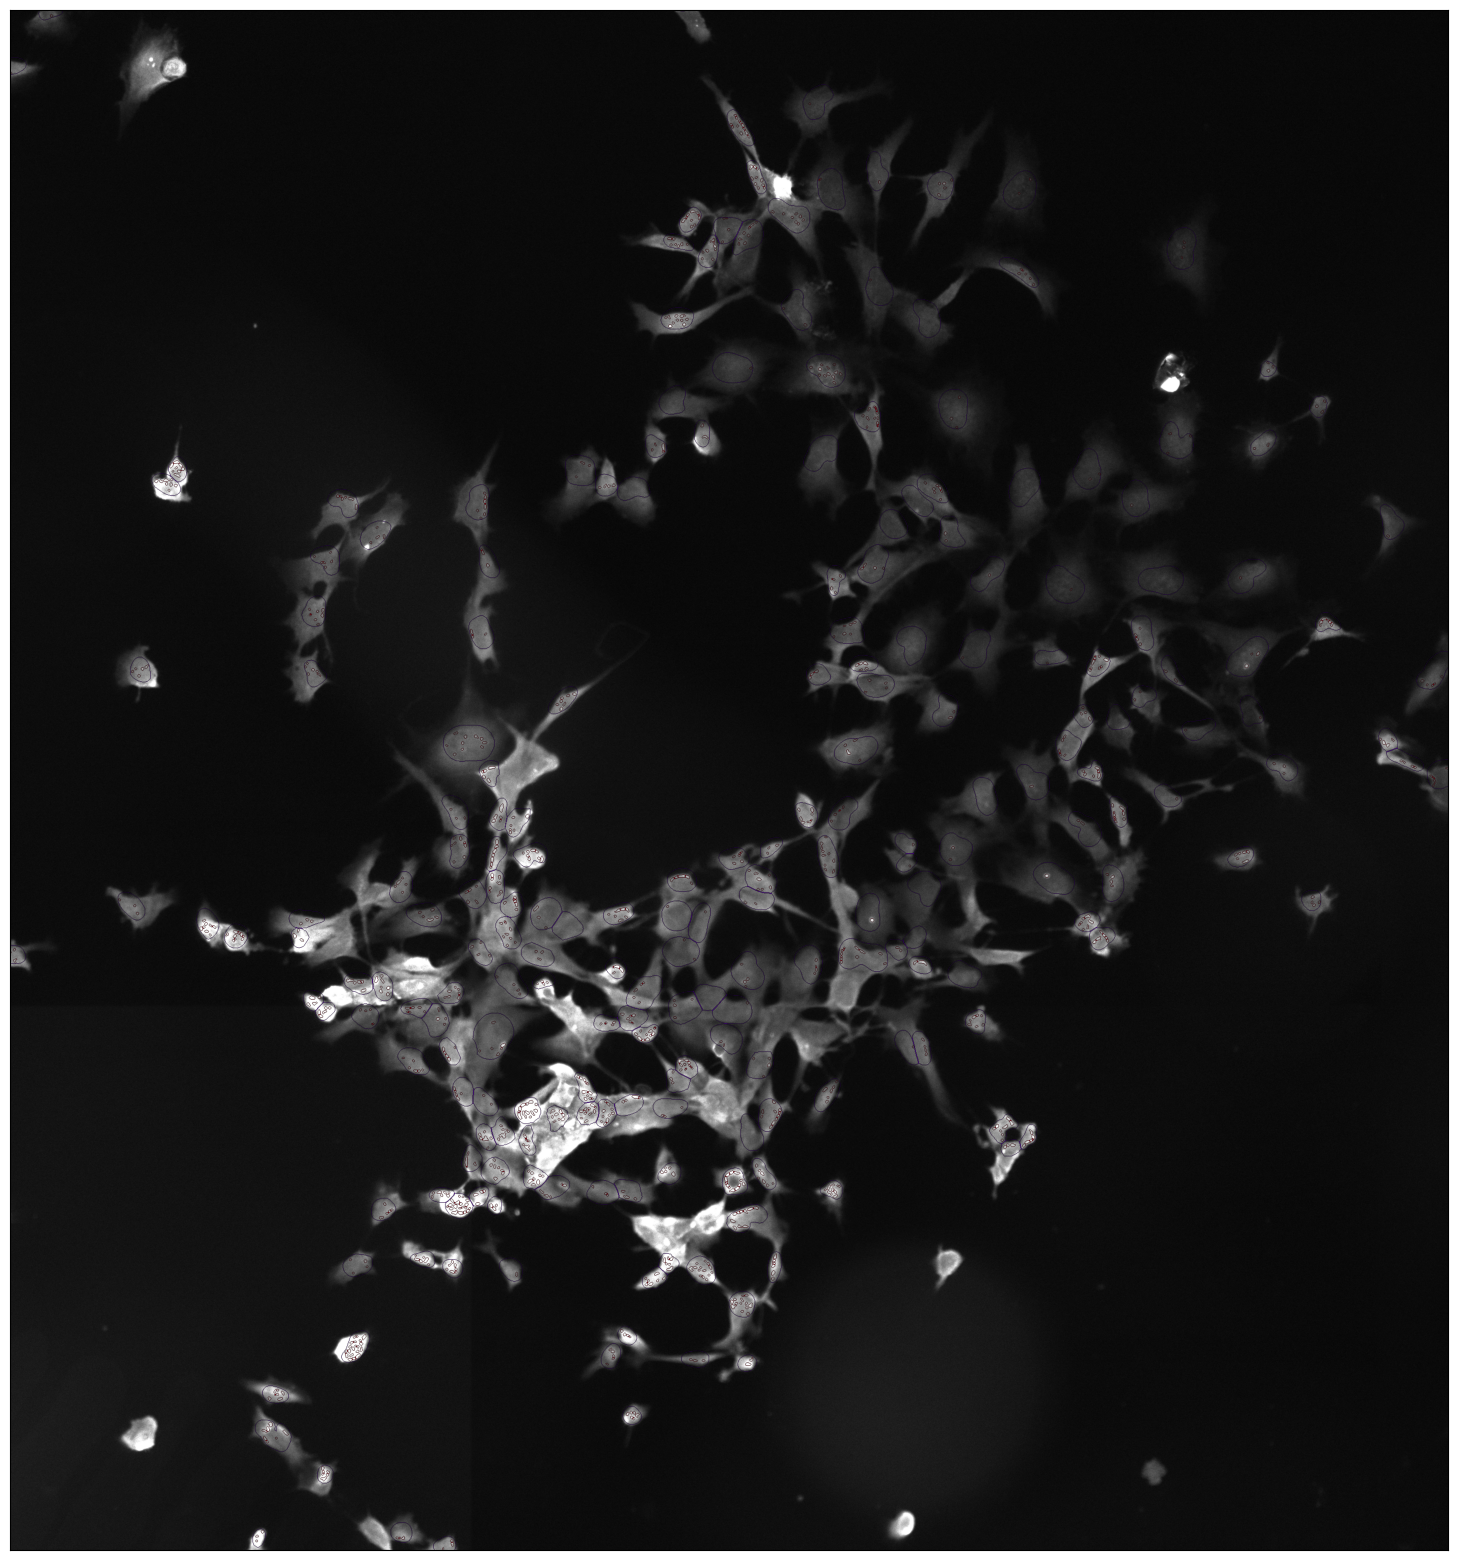

In [ ]:
col_num = 19
points = df[df["colony_id"]==col_num][['cells_i', 'cells_j']].to_numpy()
hull = ConvexHull(points)
bb = points[hull.vertices]
max = list(map(int, np.max(bb, axis=0)))
min = list(map(int, np.min(bb, axis=0)))
index = list(map(int, np.append(np.min(bb, axis=0),np.max(bb, axis=0))))
colony = subimage(np.stack((gfp,cy5)),index)
foci_colony = subimage(foci, index)
nuclei_colony = subimage(nuclei, index)
cells_colony = subimage(cells, index)


nuc_outline = ski.segmentation.find_boundaries(nuclei_colony,mode="outer")
nuc_outline = np.ma.masked_where(nuc_outline==False,nuc_outline)

foci_outline = ski.segmentation.find_boundaries(foci_colony,mode="outer")
foci_outline = np.ma.masked_where(foci_outline==False,foci_outline)

cells_outline = ski.segmentation.find_boundaries(cells_colony,mode="outer")
cells_outline = np.ma.masked_where(cells_outline==False,cells_outline)


#show = microshow(images=composite, cmaps=['pure_green','pure_magenta'], limits=[[0,4000],[0,3500]], ax=ax)



# clust1 = clust1.compute()
fig, ax = plt.subplots(figsize=(20,20))

ax.set_xticks([])
ax.set_yticks([])
ax.imshow(ski.exposure.rescale_intensity(colony[1], in_range=(0,4000)),cmap="gray")
ax.imshow(nuc_outline, cmap="Purples_r")
ax.imshow(foci_outline,cmap="Reds_r")
plt.show()

In [ ]:
group_means = df.groupby("colony_id")["foci_count"].mean()
sizes = df.groupby("colony_id").size()

T_obs = np.sum(sizes * (group_means - df["foci_count"].mean())**2)

In [ ]:
df.groupby("colony_id")["foci_count"].describe()

In [ ]:
sizes = df.groupby("colony_id").size()
df["colony_size"] = df["colony_id"].map(sizes)
df["rebound"] = df["colony_id"] != -1

In [ ]:
ttest = scipy.stats.ttest_ind(df[df["rebound"] == True]["foci_count"], df[df["rebound"] == False]["foci_count"],alternative="less")

ttest.confidence_interval(confidence_level=0.95)

In [ ]:
df_anova = df[["colony_id","foci_count","log_foci_count"]].copy()
dfs_anova = [df_anova[df_anova["colony_id"] == i]["foci_count"].values for i in np.unique(df["colony_id"].values)]

In [22]:
dfs_anova_rebound = [df_anova[df_anova["colony_id"] == i]["foci_count"].values for i in np.unique(df[df["colony_id"] != -1]["colony_id"].values)]

In [ ]:
krus_result = scipy.stats.kruskal(*dfs_anova)
krus_result.statistic

In [42]:
df_anova

,colony_id,foci_count
label,,
1,-1,4
2,-1,0
3,-1,9
4,-1,1
5,-1,2
...,...,...
4503,-1,10
4504,-1,17
4505,-1,4


In [43]:
def kruskal_perm(*arr):
    krus_result = scipy.stats.kruskal(*arr)
    return krus_result.statistic

def mannwhitneyu_perm(*arr):
    mannwhiteneyu_result = scipy.stats.mannwhitneyu(*arr)
    return mannwhiteneyu_result.statistic

In [ ]:
perm_result = scipy.stats.permutation_test(dfs_anova, kruskal_perm, permutation_type="independent")

In [45]:
perm_result

PermutationTestResult(statistic=np.float64(682.7212236997833), pvalue=np.float64(0.0002), null_distribution=array([18.44665939, 33.60013418, 36.88475004, ..., 27.36910843,
       27.32526202, 20.80541406], shape=(9999,)))

In [47]:
pvals = defaultdict(int)
for i in np.unique(df["colony_id"].values):
    foci_col = df_anova[df_anova["colony_id"] == i]["foci_count"].values
    foci_rest = df_anova[df_anova["colony_id"] != i]["foci_count"].values
    res = scipy.stats.permutation_test([foci_col, foci_rest], mannwhitneyu_perm, permutation_type="independent")
    pvals[i] = res.pvalue

In [57]:
fdr = scipy.stats.false_discovery_control(list(pvals.values()))

pvals_adj = defaultdict(int)
for i in np.unique(df["colony_id"].values):
    pvals_adj[i] = fdr[i]

In [70]:
def convert_pvalue_to_asterisks(pvalue):
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

In [71]:
df_anova["padj"] = df_anova["colony_id"].map(pvals_adj)

p_astr = defaultdict(int)
for key, val in pvals_adj.items():
    p_astr[key] = convert_pvalue_to_asterisks(val)

p_astr


defaultdict(int,
            {np.int64(-1): 'ns',
             np.int64(1): '*',
             np.int64(2): '***',
             np.int64(3): '***',
             np.int64(4): '**',
             np.int64(5): '**',
             np.int64(6): '**',
             np.int64(7): '***',
             np.int64(8): '***',
             np.int64(9): 'ns',
             np.int64(10): 'ns',
             np.int64(11): '***',
             np.int64(12): 'ns',
             np.int64(13): '*',
             np.int64(14): 'ns',
             np.int64(15): 'ns',
             np.int64(16): '***',
             np.int64(17): '*',
             np.int64(18): '***',
             np.int64(19): '***',
             np.int64(20): 'ns'})

In [ ]:
colony_stats = (
    df.groupby("rebound")["foci_count"]
    .median()
    .sort_values(ascending=True)
)

order = colony_stats.index

df_plot = df.copy()
df_plot["rebound"] = pd.Categorical(df_plot["rebound"], categories=order, ordered=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x="rebound",
    y="log_foci_count",
    showfliers=True
)

plt.xticks(rotation=90)
plt.xlabel("rebound")
plt.ylabel("Log foci count")
plt.title("Foci count distribution")

plt.show()

In [85]:
df_anova["log_foci_count"] = np.log1p(df_anova["foci_count"])
df_anova["p_display"] = df_anova["colony_id"].map(p_astr)

In [92]:
df_anova.groupby("colony_id").median(numeric_only=True)

,foci_count,padj,log_foci_count
colony_id,,,
-1,3.0,0.643705,1.386294
1,3.0,0.019200,1.386294
2,4.0,0.000467,1.609438
3,4.0,0.000467,1.609438
4,3.0,0.003818,1.386294
5,4.0,0.005250,1.609438
6,5.0,0.002940,1.791759
7,5.0,0.000467,1.791759
8,3.0,0.000467,1.386294


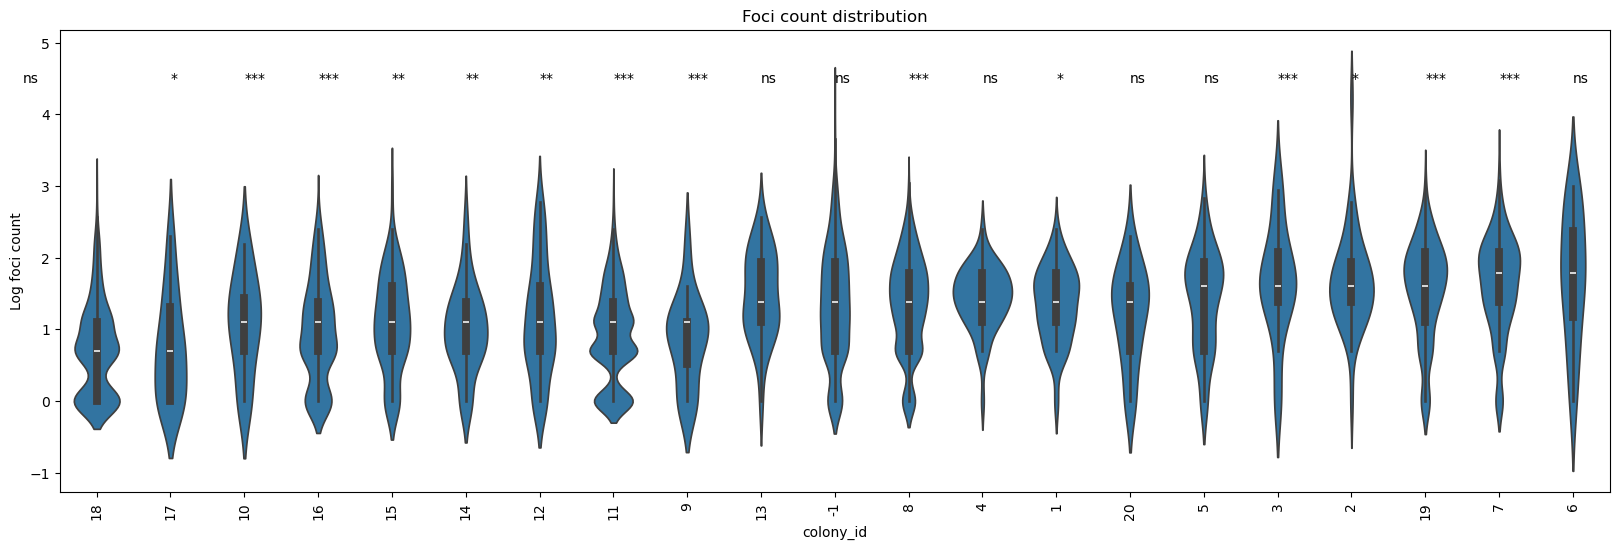

In [ ]:
colony_stats = (
    df_anova.groupby("colony_id")["foci_count"]
    .median()
    .sort_values(ascending=True)
)

order = colony_stats.index

df_plot = df.copy()
df_plot["colony_id"] = pd.Categorical(df_plot["colony_id"], categories=order, ordered=True)

ypos = df_plot["log_foci_count"].max() * 1.05

plt.figure(figsize=(20, 6))

sns.violinplot(
    data=df_plot,
    x="colony_id",
    y="log_foci_count"
)
for key, val in p_astr.items():
    plt.text(x=key, y=ypos, s=val)

plt.xticks(rotation=90)
plt.xlabel("colony_id")
plt.ylabel("Log foci count")
plt.title("Foci count distribution")

plt.show()

In [ ]:
order = df[df["colony_id"] != -1].groupby("colony_id")["foci_count"].count().sort_values(ascending=True)
order

In [ ]:
foci_by_colony = df[df["colony_id"] != -1].groupby("colony_id")["foci_count"]

order = df[df["colony_id"] != -1].groupby("colony_id")["foci_count"].count().sort_values(ascending=True)

df_plot = df.copy()
df_plot["colony_id"] = pd.Categorical(df_plot["colony_id"], categories=order.index, ordered=True)

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x="colony_id",
    y="log_foci_count",
    showfliers=True
)

plt.xticks(rotation=90)
plt.xlabel("colony_id")
plt.ylabel("Log foci count")
plt.title("Foci count distribution")

plt.show()

In [ ]:
colonysize_vs_foci

In [ ]:
grouped_colonysize_vs_foci = df[df["colony_id"] != -1].groupby("colony_id")[["foci_count", "colony_size"]].median().sort_values(by="colony_size")
colonysize_vs_foci = df[df["colony_id"] != -1][["foci_count", "colony_size", "colony_id", "log_foci_count"]]

plt.figure(figsize=(20, 6))

sns.scatterplot(
    data=colonysize_vs_foci,
    x="colony_size",
    y="log_foci_count",
    hue="colony_id"
)

plt.xticks(rotation=90)
plt.xlabel("Colony_size")
plt.ylabel("Foci count")


plt.title("Foci count distribution")

plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_plot,
    x="colony_id",
    y="foci_count",
    scale="width",
    inner="quartile"
)

plt.xticks(rotation=90)
plt.show()

In [ ]:
plt.figure(figsize=(20, 6))

sns.boxplot(
    data=df_plot,
    x="colony_id",
    y="foci_count",
    showfliers=False
)

sns.stripplot(
    data=df_plot,
    x="colony_id",
    y="foci_count",
    color="black",
    size=2,
    alpha=0.3
)

plt.xticks(rotation=90)
plt.show()

In [ ]:
import scipy.stats as stats

groups = [g["foci_count"].values for _, g in df.groupby("colony_id")]

F_obs, h = stats.f_oneway(*groups)

In [ ]:
groups = [g[["foci_count"]].values for _, g in df.groupby("colony_id")]

In [ ]:
groups = [g["log_foci"].values for _, g in df.groupby("colony_id")]

F_obs, p = stats.kruskal(*groups)

In [ ]:
df_test = df[df["colony_id"] != -1]

foci = df_test["foci_count"].values
colony = df_test["colony_id"].values

group_means = df_test.groupby("colony_id")["foci_count"].mean()
sizes = df_test.groupby("colony_id").size()

T_obs = np.sum(sizes * (group_means - foci.mean())**2)

n_perm = 1000
T_perm = []

for _ in range(n_perm):
    perm_colony = np.random.permutation(colony)
    df_test["perm_colony"] = perm_colony

    gm = df_test.groupby("perm_colony")["foci_count"].mean()
    sz = df_test.groupby("perm_colony").size()

    T_perm.append(np.sum(sz * (gm - foci.mean())**2))

p_value = (np.sum(np.array(T_perm) >= T_obs) + 1) / (n_perm + 1)

In [ ]:
foci = df["foci_count"].values
colony = df["colony_id"].values

# compute observed statistic
def between_group_ss(foci, labels):
    unique = np.unique(labels)
    overall_mean = foci.mean()

    ss = 0.0
    for u in unique:
        mask = labels == u
        if mask.sum() == 0:
            continue
        mu = foci[mask].mean()
        ss += mask.sum() * (mu - overall_mean)**2
    return ss

T_obs = between_group_ss(foci, colony)

In [ ]:
n_perm = 2000
T_perm = np.zeros(n_perm)

for k in range(n_perm):
    perm_colony = np.random.permutation(colony)
    T_perm[k] = between_group_ss(foci, perm_colony)

In [ ]:
p_value = (np.sum(T_perm >= T_obs) + 1) / (n_perm + 1)

In [ ]:
foci = df["log_foci"].values
colony = df["colony_id"].values

unique_colonies = np.unique(colony)

n_perm = 2000
results = []

for c in unique_colonies:
    mask = colony == c

    if mask.sum() < 5:
        continue  # skip very small groups

    foci_in = foci[mask]
    foci_out = foci[~mask]

    T_obs = np.mean(foci_in) - np.mean(foci_out)

    T_perm = np.zeros(n_perm)

    for k in range(n_perm):
        perm_labels = np.random.permutation(mask)
        foci_in_perm = foci[perm_labels]
        foci_out_perm = foci[~perm_labels]

        T_perm[k] = np.mean(foci_in_perm) - np.mean(foci_out_perm)

    p = (np.sum(np.abs(T_perm) >= np.abs(T_obs)) + 1) / (n_perm + 1)

    results.append((c, T_obs, p))

In [ ]:
from statsmodels.stats.multitest import multipletests

pvals = [r[2] for r in results]
reject, pvals_corr, _, _ = multipletests(pvals, method="fdr_bh")

results_corr = [
    (r[0], r[1], r[2], pvals_corr[i], reject[i])
    for i, r in enumerate(results)
]

In [ ]:
nobjects = np.max(labels)
object_indexes = np.arange(nobjects, dtype=np.int32) + 1
distance = 57
strel = strel_disk(distance)

objs = ndi.find_objects(labels, max_label=nobjects)
# objs is a list of slice-tuples, one per label 1..nobjects
# missing labels give None

minimums_i = np.empty(nobjects, dtype=np.int64)
maximums_i = np.empty(nobjects, dtype=np.int64)
minimums_j = np.empty(nobjects, dtype=np.int64)
maximums_j = np.empty(nobjects, dtype=np.int64)

for k, slc in enumerate(objs):
    if slc is None:
        minimums_i[k] = 0
        maximums_i[k] = 0
        minimums_j[k] = 0
        maximums_j[k] = 0
        continue

    si, sj = slc
    minimums_i[k] = max(si.start - distance, 0)
    maximums_i[k] = min(si.stop  + distance, labels.shape[0])
    minimums_j[k] = max(sj.start - distance, 0)
    maximums_j[k] = min(sj.stop  + distance, labels.shape[1])

In [ ]:
def cv(x):
    return x.std() / x.mean()

# Apply multiple functions
df.groupby('colony_id')['foci_count'].agg(['mean', 'std', cv]).sort_values("std")

In [ ]:
from sklearn.neighbors import NearestNeighbors

coords = df[["nucleus_i","nucleus_j"]].values

nbrs = NearestNeighbors(n_neighbors=10).fit(coords)
distances, indices = nbrs.kneighbors(coords)

nbrs_edges = set()

k = 5

for i in range(len(coords)):
    for j in indices[i, 1:k+1]:
        if i in indices[j, 1:k+1]:
            nbrs_edges.add(tuple(sorted((i, j))))

In [ ]:
G = nx.Graph()
G.add_nodes_from(object_indexes)
G.add_edges_from(edges)
components_nbrs = list(nx.connected_components(G))
colony_map_nbrs = {}
i = 1
for comp in components_nbrs:
    if len(comp) < 10:
        for cell_id in comp:
            colony_map_nbrs[cell_id] = -1
    else:
        for cell_id in comp:
            colony_map_nbrs[cell_id] = i
        i += 1
df["colony_id_nbrs"] = df.index.map(colony_map)
np.unique(df["colony_id_nbrs"].values)

In [ ]:
points = df[df["colony_id"]==6][['cells_i', 'cells_j']].to_numpy()
hull = ConvexHull(points)
bb = points[hull.vertices]
max = list(map(int, np.max(bb, axis=0)))
min = list(map(int, np.min(bb, axis=0)))
inde = list(map(int, np.append(np.min(bb, axis=0),np.max(bb, axis=0))))
# # draw edges
# for simplex in hull.simplices:
#     ax.plot(points[simplex, 0], points[simplex, 1],
#         color='red', linewidth=1)

In [ ]:
max_label = labels.max()

label_to_colony = np.full(max_label + 1, 0, dtype=int)
for cell_id, colony_id in colony_map.items():
    label_to_colony[cell_id] = colony_id
    
colony_img = label_to_colony[labels]

ids = np.unique(colony_img)
ids = ids[ids>0]
cmap = plt.get_cmap("tab20", len(ids))

label_to_color = {
    lab: cmap(i)
    for i, lab in enumerate(ids)
}

# set background / non-colony
label_to_color[-1] = (0.7, 0.7, 0.7, 1)
label_to_color[0] = (0,0,0, 1)

colors_array = np.zeros((max_label + 1, 4))

for lab, color in label_to_color.items():
    colors_array[lab] = color

rgb = colors_array[colony_img]

fig, ax = plt.subplots(figsize=(10,10))
ax.set_xticks([])
ax.set_yticks([])
plt.imshow(rgb)

In [ ]:
hull7 = ConvexHull(df[df["colony_id"]==7][['cells_i', 'cells_j']].to_numpy())

In [ ]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set_xticks([])
ax.set_yticks([])
h = convex_hull_plot_2d(hull7, ax=ax)
plt.imshow(labels_full)

In [ ]:
label_to_colony = np.full(max_label + 1, 0, dtype=int)
for cell_id, colony_id in colony_map.items():
    label_to_colony[cell_id] = colony_id
    
colony_img = label_to_colony[labels]

In [ ]:
# labels,_,_ = ski.segmentation.relabel_sequential(labels, offset=1)
# labels = da.from_array(labels)
nobjects = np.max(labels)
object_indexes = np.arange(nobjects, dtype=np.int32) + 1
distance = 25
strel = strel_disk(distance)

In [ ]:
def prepare_box_for_contours(box, shape, pad=3):
    """Marginally pads a bounding box so that object boundaries
    are not on cropped image patch edges.
    """
    for i in range(2):
        box[i] = max(0, box[i] - pad)
        box[i+2] = min(shape[i], box[i+2] + pad)
    slices = tuple([slice(box[i], box[i+2]) for i in range(2)])
    top_left = np.array(box[:2])[None] # (1, 2)
    return slices, top_left

def make_polygons_from_mask(mask):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    polygons = {}
    for rp in measure.regionprops(mask):
        # Faster to compute contours on small cell tiles than the whole image
        box_slices, box_top_left = prepare_box_for_contours(list(rp.bbox), mask.shape)
        label_mask = mask[box_slices] == rp.label

        label_cnts = np.concatenate(
            measure.find_contours(label_mask), axis=0
        )

        polygons[rp.label] = Polygon(label_cnts + box_top_left)
    
    return polygons

def make_polygons_from_boxes(mask, labels):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    polygons = {}
    for lab in labels:
        box = subimage(mask, cell_coords.at[lab, "cells_bounds"], pad=5)
        box_top_left = np.array(cell_coords.at[lab, "cells_bounds"][:2])[None]

        label_cnts = np.concatenate(
            measure.find_contours(box), axis=0
        )

        polygons[lab] = Polygon(label_cnts + box_top_left)
    
    return polygons

def make_hull_from_boxes(mask, labels):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    hulls = {}
    for lab in labels:
        box = subimage(mask, cell_coords.at[lab, "cells_bounds"], pad=5)
        box_top_left = np.array(cell_coords.at[lab, "cells_bounds"][:2])[None]

        label_cnts = np.concatenate(
            measure.find_contours(box), axis=0
        )

        hulls[lab] = ConvexHull(label_cnts + box_top_left)
    
    return hulls

def make_delaunay_from_boxes(mask, labels):
    """Constructs a polygon for each object in a mask. Returns
    a dict where each key is a label id and values are shapely polygons.
    """
    tris = {}
    for lab in labels:
        box = subimage(mask, cell_coords.at[lab, "cells_bounds"], pad=5)
        box_top_left = np.array(cell_coords.at[lab, "cells_bounds"][:2])[None]

        label_cnts = np.concatenate(
            measure.find_contours(box), axis=0
        )

        tris[lab] = Delaunay(label_cnts + box_top_left)
    
    return tris

def pairwise_polygon_distance(polygons_dict, dist):
    """Computes pairwise distance between all polygons in
    a dictionary. Returns a dictionary of distances.
    """
    polys = list(polygons_dict.values())
    ids = list(polygons_dict.keys())

    tree = STRtree(polys)

    id_map = dict(zip(polys, ids))

    distances = {i: {} for i in ids}

    for poly in polys:
        i = id_map[poly]

        # query nearby polygons using bounding boxes
        candidates = tree.query(poly.buffer(dist))  # 5 px search radius

        for other in candidates:
            j = id_map[other]
            if i == j:
                continue

            d = poly.distance(other)
            distances[i][j] = d
                
    return distances

def get_contour_from_label(mask, labels, df = cell_coords, scaled=True):
    contours = defaultdict(int)
    if not isinstance(labels, list):
        labels = list(labels)
    
    for label in labels:
        box = subimage(mask, df.at[label, "cells_bounds"], pad=5)

        label_cnts = np.concatenate(
        measure.find_contours(box), axis=0
            )
        
        if scaled:
            box_top_left = np.array(df.at[label, "cells_bounds"][:2])[None]
            contours[label] = label_cnts + box_top_left
        else:
            contours[label] = label_cnts
            
    return contours

In [ ]:
objs = ndi.find_objects(labels, max_label=nobjects)
# objs is a list of slice-tuples, one per label 1..nobjects
# missing labels give None

minimums_i = np.empty(nobjects, dtype=np.int64)
maximums_i = np.empty(nobjects, dtype=np.int64)
minimums_j = np.empty(nobjects, dtype=np.int64)
maximums_j = np.empty(nobjects, dtype=np.int64)

for k, slc in enumerate(objs):
    if slc is None:
        minimums_i[k] = 0
        maximums_i[k] = 0
        minimums_j[k] = 0
        maximums_j[k] = 0
        continue

    si, sj = slc
    minimums_i[k] = max(si.start - distance, 0)
    maximums_i[k] = min(si.stop  + distance, labels.shape[0])
    minimums_j[k] = max(sj.start - distance, 0)
    maximums_j[k] = min(sj.stop  + distance, labels.shape[1])

In [ ]:
max_label = dilated_region.max()

label_to_colony = np.full(max_label + 1, 0, dtype=int)
for cell_id, colony_id in colony_map.items():
    label_to_colony[cell_id] = colony_id
    
colony_img = label_to_colony[dilated_region]

ids = np.unique(colony_img)
ids = ids[ids>0]
cmap = plt.get_cmap("tab20", len(ids))

label_to_color = {
    lab: cmap(i)
    for i, lab in enumerate(ids)
}

# set background / non-colony
label_to_color[-1] = (0.7, 0.7, 0.7, 1)
label_to_color[0] = (0,0,0, 1)

colors_array = np.zeros((max_label + 1, 4))

for lab, color in label_to_color.items():
    colors_array[lab] = color

rgb = colors_array[colony_img]


plt.imshow(rgb)

In [ ]:
colony_map = {}
for k, comp in enumerate(components, start=1):
    if len(comp) < 3:
        for cell_id in comp:
            colony_map[cell_id] = -1
    else:
        for cell_id in comp:
            colony_map[cell_id] = k

cell_coords["colony_id"] = cell_coords.index.map(colony_map)

# sizes = df["colony_id_poly"].value_counts()

# valid = sizes[sizes >= 10].index

# df["in_colony"] = df["colony_id_poly"].isin(valid)

In [ ]:
distances = pd.DataFrame(distances_dict)
distances_flat = distances.to_numpy().flatten()
distances_flat = distances_flat[~np.isnan(distances_flat)]

In [ ]:
G = nx.Graph()

# add all cells
G.add_nodes_from(polygons_dict.keys())

threshold = 20  # adjust

for i, neighbors in distances_dict.items():
    for j, d in neighbors.items():
        if d <= threshold:
            G.add_edge(i, j)

components = list(nx.connected_components(G))

colony_map = {}
for k, comp in enumerate(components):
    for cell_id in comp:
        colony_map[cell_id] = k

df["colony_id_poly"] = df.index.map(colony_map)

sizes = df["colony_id_poly"].value_counts()

valid = sizes[sizes >= 10].index

df["in_colony"] = df["colony_id_poly"].isin(valid)

In [ ]:
# sizes = df["colony_id"].value_counts()

# valid = sizes[sizes >= 10].index

# df["in_colony"] = df["colony_id"].isin(valid)

# labels = df["colony_id"].values
# unique_labels = np.unique(labels)

# # assign a color to each label
# colors_map = {
#     lab: plt.cm.Spectral(i / len(unique_labels))
#     for i, lab in enumerate(unique_labels)
# }

# # override noise (-1) to black
# filtered_dict = {key:(value if np.isin(key,valid)
#           else (0, 0, 0, 1)) for key, value in colors_map.items()}

# # build color list per point
# colors = [filtered_dict[lab] for lab in labels]

fig, ax = plt.subplots()

ax.scatter(
    df["nucleus_j"],
    df["nucleus_j"],
    c=df["foci_count"],
    s=5
)

ax.set_xticks([])
ax.set_yticks([])
ax.invert_yaxis()

# ax[1].imshow(ski.exposure.rescale_intensity(img[1], in_range=(0,3000)))
# ax[1].set_xticks([])
# ax[1].set_yticks([])
plt.tight_layout()
plt.show()

In [ ]:
np.log

In [ ]:
df["log_foci_count"] = np.log1p(df["foci_count"])
points = df[df["colony_id"]==7][['cells_i', 'cells_j']].to_numpy()
hull7 = ConvexHull(points)

In [ ]:
for colony_id, subdf in df.groupby("colony_id"):
    if colony_id == -1:
        continue
    points = subdf[['cells_i', 'cells_j']].to_numpy()
    hull = ConvexHull(points)

    # draw edges
    for simplex in hull.simplices:
        ax.plot(points[simplex, 0], points[simplex, 1],
                color='red', linewidth=1)